### Reproduce Mania et al. Model similarity Appendix C Fig 4

In [25]:
y_true_income = data['ACSIncome'][1]
predictions_income = risk_score_to_prediction(risk_scores_0["ACSIncome"], binarize_fun=partial(binarize_using_threshold, evals=evals_0['ACSIncome']))
N, M = predictions_income.shape
N

166450

In [26]:
wrongly_classfied = predictions_income.apply(lambda x: (x != y_true_income).astype(int), axis=0).loc[y_true_income==0]
N = wrongly_classfied.shape[0]
#wrongly_classfied.sum(axis=1).sort_values(axis=0, ascending=False)

In [27]:
wrongly_classfied

,allenai--OLMo-1B-hf,meta-llama--Meta-Llama-3.2-1B,allenai--OLMo-1B-0724-hf,meta-llama--Meta-Llama-3.2-1B-Instruct,google--gemma-2b,google--gemma-1.1-2b-it,meta-llama--Meta-Llama-3.2-3B,meta-llama--Meta-Llama-3.2-3B-Instruct,01-ai--Yi-6B,01-ai--Yi-6B-Chat,...,meta-llama--Meta-Llama-3.1-70B,meta-llama--Meta-Llama-3.1-70B-Instruct,meta-llama--Meta-Llama-3-70B-Instruct,meta-llama--Meta-Llama-3.3-70B-Instruct,Qwen--Qwen2.5-72B,Qwen--Qwen2-72B,Qwen--Qwen2.5-72B-Instruct,Qwen--Qwen2-72B-Instruct,mistralai--Mixtral-8x22B-v0.1,mistralai--Mixtral-8x22B-Instruct-v0.1
238351,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2995677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1924596,0,1,0,0,0,0,1,1,0,1,...,1,1,0,0,0,0,0,0,1,1
2784255,1,0,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
2809101,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3164791,0,1,0,1,0,0,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
43637,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2494279,1,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2989522,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


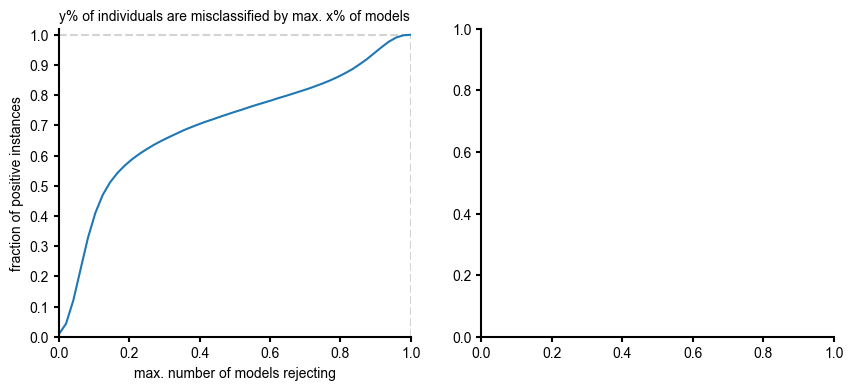

In [28]:
counts_wrongly_classified = [(i, (wrongly_classfied.sum(axis=1) == i).sum()) for i in range(M+1)]
x, y = zip(*counts_wrongly_classified)
fig, ax = plt.subplots(1,2,figsize=(10,4))
#fig.suptitle()
# aboslute number of models
ax[0].set_ylim(0,1.02)
ax[0].set_xlim(0,1.0)
ax[0].set_xlabel('max. number of models rejecting')
ax[0].set_ylabel('fraction of positive instances')
ax[0].set_title('y% of individuals are misclassified by max. x% of models')
ax[0].hlines(y=1.0, xmin=0.0, xmax=1.0, colors='lightgrey', linestyle='dashed')
ax[0].vlines(x=1.0, ymin=0.0, ymax=1.0, colors='lightgrey', linestyle='dashed')
ax[0].plot(np.array(x)/M, np.cumsum(y)/N)
# ax[0].scatter(np.array(x)/M, np.cumsum(y)/N)
ax[0].set_yticks(np.arange(0.0,1.1, 0.1))

# # fraction
# ax[1].set_xlim(0,1.0)
# ax[1].set_ylim(0,1.02)
# ax[1].set_xlabel('min. fraction of models misclassifiying')
# ax[1].set_ylabel('fraction of individuals')
# ax[1].set_title('y% of individuals are misclassified by min. x% of models')
# ax[1].hlines(y=1.0, xmin=0.0, xmax=1.0, colors='lightgrey', linestyle='dashed')
# ax[1].vlines(x=1.0, ymin=0.0, ymax=1.0, colors='lightgrey', linestyle='dashed')
# ax[1].plot(np.array(x)/M, np.cumsum(np.array(y)[::-1])[::-1]/N) # not the same as 1-np.cumsum!
# ax[1].set_yticks(np.arange(0.0,1.1, 0.1))
# plt.show()
    